# MNIST evaluation notebook (SNN vs MC Dropout vs EDL)

Thin notebook wrapper around `snn_eval.run_mnist`. Every training / inference / metrics / plotting step below calls `run_mnist.compute()` and `run_mnist.display()` directly — nothing here re-implements that logic, so any fix made in `run_mnist.py` is picked up automatically next time this notebook runs.

Section 2 shows the one extension point (`compute(args, loader=..., exp_name=...)`) that lets this same pipeline run against another MNIST-shaped dataset without touching training/inference/metrics code.

In [1]:
!git clone https://github.com/Ouatt-Isma/Subjective-Neural-Network-Framework.git
%cd Subjective-Neural-Network-Framework
!pip install -q -r requirements.txt

fatal: destination path 'Subjective-Neural-Network-Framework' already exists and is not an empty directory.
/content/Subjective-Neural-Network-Framework


In [2]:
!cat requirements.txt

# ── CUDA wheels (CUDA 12.1) ────────────────────────────────────────────────
# Install with:
#   pip install -r requirements.txt --extra-index-url https://download.pytorch.org/whl/cu121
# For CUDA 12.4 replace cu121 with cu124; for CPU-only drop the flag entirely.
--extra-index-url https://download.pytorch.org/whl/cu121

# ── Core ───────────────────────────────────────────────────────────────────
torch>=2.3.0
torchvision>=0.18.0
numpy>=1.23
scipy>=1.9
tqdm>=4.65

# ── Optional: frozen-backbone experiments ─────────────────────────────────
# timm>=0.9          # timm backbone (run_exp1 --backbone <timm-model>)
# matplotlib>=3.7    # rotation-sweep plots (run_mnist --plot)


In [3]:
%matplotlib inline
import argparse
import pandas as pd
from snn_eval import run_mnist, cache

In [4]:
def run_cached(exp_name, args, loader=None):
    """Thin caching wrapper around run_mnist.compute(), mirroring run_mnist.main().

    Avoids retraining / re-running inference on every notebook re-run: results
    are keyed by all params (like the CLI's results cache) and models by the
    train-only subset (like the CLI's model cache, handled inside compute()
    itself). Delete results/cache or results/models to force a clean re-run.
    """
    params = {k: v for k, v in vars(args).items() if k not in ("device", "no_cache")}
    res = None if args.no_cache else cache.load_results(exp_name, params)
    if res is None:
        res = run_mnist.compute(args, loader=loader, exp_name=exp_name)
        cache.save_results(exp_name, params, res)
    return res

## 1. MNIST (default loader)

`build_argparser()` is the exact same parser `run_mnist.py` uses from the CLI, so `parse_args([])` gives a `Namespace` of CLI defaults — tweak individual fields below instead of re-typing them.

In [5]:
args = run_mnist.build_argparser().parse_args([])  # identical defaults to the CLI
args.arch = "resnet"  # "mlp" | "cnn" | "resnet"
args.device  = "cuda"     # you're on Colab — use the GPU instead of "cpu"
args.epochs  = 15
args.Np      = 10
args.Nm      = 10
args.beta_max = 10
args.device = "cuda"
QUICK = False  # flip to False for the full paper-grade run
if QUICK:
    args.epochs, args.Np, args.Nm, args.T = 2, 3, 3, 20
    args.rot_step, args.rot_n = 45, 200

vars(args)

{'arch': 'resnet',
 'synthetic': False,
 'device': 'cuda',
 'epochs': 15,
 'd_hidden': 256,
 'beta_max': 10,
 'Np': 10,
 'Nm': 10,
 'T': 100,
 'rot_step': 15,
 'rot_n': 1000,
 'seed': 0,
 'n_train': 60000,
 'label_noise': 0.0,
 'no_cache': False}

In [6]:
res = run_cached("run_mnist", args)

[results] hit  ← results/cache/run_mnist_5057d4d5b8b3_results.json



arch=resnet

Model                 Acc    NLL    ECE OOD-AUROC
MC Dropout          0.991  0.029  0.003     0.968
MCD (mean, H)       0.991  0.029  0.003     0.969
MCD (u* BALD)       0.991  0.029  0.003     0.293
EDL                 0.986  0.109  0.062     0.980
SNN (mean, H)       0.994  0.021  0.003     0.974
SNN (u* counts)     0.994  0.021  0.003     0.535
SNN (aug P soft)    0.994  0.129  0.103     0.367

Rotation sweep (means over 1000 digits)
  deg |   acc  SNN u*  SNN u_e SNN u_a SNN H  | MCD H  MCD epi MCD ale | MCD u* MCD u_e MCD u_a | EDL u  EDL H 
    0 | 0.992  0.005   0.0009  0.003   0.479  | 0.027  0.0012  0.012   | 0.139  0.0030  0.024   | 0.093  0.419 
   15 | 0.966  0.007   0.0019  0.009   0.490  | 0.070  0.0026  0.031   | 0.132  0.0069  0.063   | 0.134  0.524 
   30 | 0.847  0.029   0.0080  0.035   0.573  | 0.231  0.0087  0.104   | 0.118  0.0213  0.209   | 0.319  0.947 
   45 | 0.583  0.070   0.0210  0.090   0.734  | 0.371  0.0150  0.164   | 0.118  0.0368  0.334   |

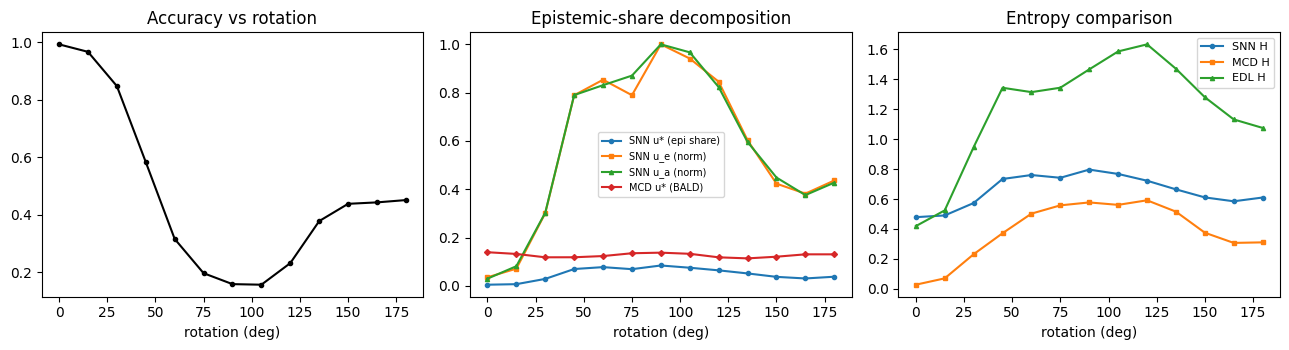

In [7]:
fig = run_mnist.display(res)  # prints tables + sweep, saves results/rotation_sweep.{csv,png}, shows inline

In [8]:
pd.DataFrame(res["table"])

,name,acc,nll,ece,ood_auroc
0,MC Dropout,0.9906,0.029249,0.002939,0.967771
1,"MCD (mean, H)",0.9906,0.029249,0.002939,0.968585
2,MCD (u* BALD),0.9906,0.029249,0.002939,0.293082
3,EDL,0.9863,0.109434,0.062097,0.980359
4,"SNN (mean, H)",0.9941,0.021414,0.002785,0.973999
5,SNN (u* counts),0.9941,0.021414,0.002785,0.534601
6,SNN (aug P soft),0.9941,0.128752,0.103425,0.367369


## 2. Adapting to another dataset

`compute()` accepts a `loader` — any zero-arg callable returning `((Xtr, ytr), (Xte, yte), Xood)` with images shaped `(N, 1, 28, 28)` and integer labels, exactly like `run_mnist.load_mnist`. Pass a different one and the rest of the pipeline (model build, training, nested sampling, MC Dropout, EDL, metrics, rotation sweep, plotting) is untouched — `compute()` now infers `K` from the labels rather than hardcoding 10.

Use a distinct `exp_name` so the alternate run's model/result cache doesn't collide with the MNIST one, and a distinct `out_prefix` in `display()` so the CSV/PNG don't overwrite `rotation_sweep.*`.

**Scope caveat:** the CNN/ResNet backbones in `models.py` (`_CNNBackbone`, `_TinyResNet`) are hardcoded for single-channel 28×28 input, so this loader-swap trick is only valid for other MNIST-shaped datasets (FashionMNIST, KMNIST, EMNIST, ...). For a genuinely different shape/channel-count/class-count (e.g. CIFAR-10), use the repo's other evaluation-ladder rungs instead — `run_exp1.py` (frozen DINOv2/CLIP backbone) or `train_fullnet.py` (full ResNet18/WRN-28-10) — rather than forcing this MNIST pipeline.

In [9]:
def load_fashion_as_id(root="./data", ntr=60000, nte=10000):
    """Same return contract as run_mnist.load_mnist, but FashionMNIST is ID and
    MNIST is OOD (roles swapped). Swap the dataset names for KMNIST/EMNIST etc.
    """
    import torch
    import torchvision as tv, torchvision.transforms as T
    tf = T.ToTensor()
    tr  = tv.datasets.FashionMNIST(root, train=True,  download=True, transform=tf)
    te  = tv.datasets.FashionMNIST(root, train=False, download=True, transform=tf)
    ood = tv.datasets.MNIST(root, train=False, download=True, transform=tf)
    def imgs(ds, n):
        X = torch.stack([ds[i][0] for i in range(min(n, len(ds)))])
        y = torch.tensor([ds[i][1] for i in range(min(n, len(ds)))])
        return X, y
    return imgs(tr, ntr), imgs(te, nte), imgs(ood, nte)[0]

arch=resnet  train=60000  test=10000  hidden=256

[training SNN]


Epoch 1/15: 100%|██████████| 937/937 [00:38<00:00, 24.08it/s]


  ep   1/15 loss=0.5002 tr_acc=0.8200 te_acc=0.8394 kl=22.8 beta=6.66 std(E[p])=0.0064


Epoch 2/15: 100%|██████████| 937/937 [00:39<00:00, 23.61it/s]


  ep   2/15 loss=0.3045 tr_acc=0.8907 te_acc=0.8899 kl=20.2 beta=10.00 std(E[p])=0.0049


...

  120°  acc=0.120  SNN u*=0.114 u_e=0.0450  MCD u*=0.087 u_e=0.0583  H=0.941


  135°  acc=0.155  SNN u*=0.115 u_e=0.0469  MCD u*=0.082 u_e=0.0516  H=0.947


  150°  acc=0.226  SNN u*=0.104 u_e=0.0357  MCD u*=0.081 u_e=0.0430  H=0.877


  165°  acc=0.225  SNN u*=0.084 u_e=0.0266  MCD u*=0.070 u_e=0.0316  H=0.798


  180°  acc=0.219  SNN u*=0.069 u_e=0.0203  MCD u*=0.073 u_e=0.0364  H=0.734
[results] saved → results/cache/fashion_mnist_d61111a671bf_results.json

arch=resnet

Model                 Acc    NLL    ECE OOD-AUROC
MC Dropout          0.924  0.223  0.029     0.838
MCD (mean, H)       0.924  0.223  0.029     0.852
MCD (u* BALD)       0.924  0.223  0.029     0.532
EDL                 0.906  0.548  0.162     0.392
SNN (mean, H)       0.933  0.224  0.029     0.776
SNN (u* counts)     0.933  0.224  0.029     0.436
SNN (aug P soft)    0.933  0.292  0.074     0.706

Rotation sweep (means over 1000 digits)
  deg |   acc  SNN u*  SNN u_e SNN u_a SNN H  | MCD H  MCD epi MCD ale | MCD u* MCD u_e MCD u_a | EDL u  EDL H 
    0 | 0.935  0.008   0.0019  0.008   0.492  | 0.121  0.0019  0.062   | 0.094  0.0056  0.116   | 0.283  0.892 
   15 | 0.757  0.029   0.0096  0.047   0.587  | 0.460  0.0071  0.220   | 0.072  0.0204  0.439   | 0.657  1.705 
   30 | 0.357  0.103   0.0371  0.160   0.885  | 0.813  0.015

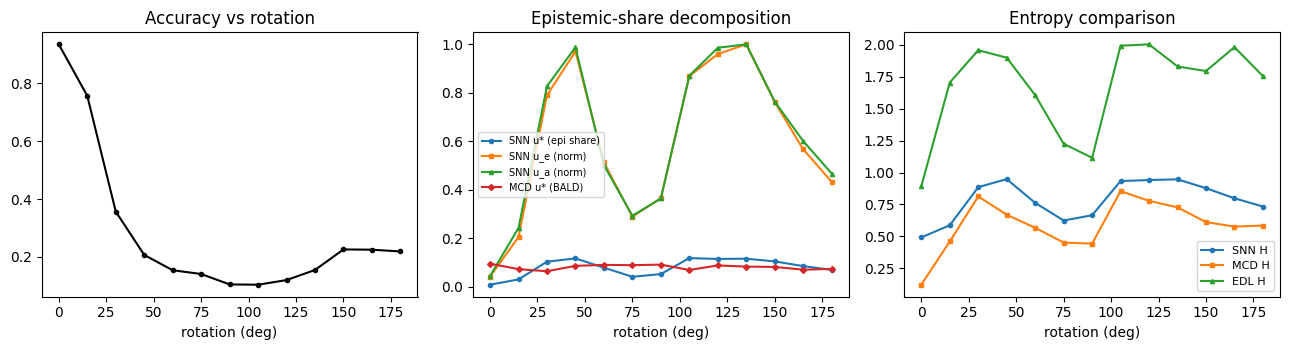

In [10]:
args_fashion = argparse.Namespace(**vars(args))  # same knobs, incl. QUICK tweaks

res_fashion = run_cached("fashion_mnist", args_fashion, loader=load_fashion_as_id)
fig_fashion = run_mnist.display(res_fashion, out_prefix="fashion_rotation_sweep")

## 3. Compare datasets side by side

Both `res` dicts came from the same `compute()`, so the table rows line up directly — no metric recomputation here, just reshaping already-computed numbers.

In [11]:
t1 = pd.DataFrame(res["table"]).assign(dataset="MNIST")
t2 = pd.DataFrame(res_fashion["table"]).assign(dataset="FashionMNIST(ID)/MNIST(OOD)")
pd.concat([t1, t2]).set_index(["dataset", "name"])

acc       nll       ece  \
dataset                     name                                           
MNIST                       MC Dropout        0.9906  0.029249  0.002939   
                            MCD (mean, H)     0.9906  0.029249  0.002939   
                            MCD (u* BALD)     0.9906  0.029249  0.002939   
                            EDL               0.9863  0.109434  0.062097   
                            SNN (mean, H)     0.9941  0.021414  0.002785   
                            SNN (u* counts)   0.9941  0.021414  0.002785   
                            SNN (aug P soft)  0.9941  0.128752  0.103425   
FashionMNIST(ID)/MNIST(OOD) MC Dropout        0.9241  0.222859  0.028666   
                            MCD (mean, H)     0.9241  0.222859  0.028666   
                            MCD (u* BALD)     0.9241  0.222859  0.028666   
                            EDL               0.9056  0.548145  0.162239   
                            SNN (mean, H)     0.9326  0.223822  0.029080   
                            SNN (u* counts)   0.9326  0.223822  0.029080   
                            SNN (aug P soft)  0.9326  0.291505  0.073978   

                                              ood_auroc  
dataset                     name                         
MNIST                       MC Dropout         0.967771  
                            MCD (mean, H)      0.968585  
                            MCD (u* BALD)      0.293082  
                            EDL                0.980359  
                            SNN (mean, H)      0.973999  
                            SNN (u* counts)    0.534601  
                            SNN (aug P soft)   0.367369  
FashionMNIST(ID)/MNIST(OOD) MC Dropout         0.838244  
                            MCD (mean, H)      0.851850  
                            MCD (u* BALD)      0.532418  
                            EDL                0.392146  
                            SNN (mean, H)      0.775998  
                            SNN (u* counts)    0.435845  
                            SNN (aug P soft)   0.706343

## 4. Epistemic probe — data scarcity (n_train sweep)

Train SNN / MC Dropout / EDL on progressively smaller fractions of MNIST (100 → 60 k samples).
With less data the trust parameters have fewer gradient steps to converge → they stay in the diffuse `epistemic_flat` / `epistemic_u` regime → different outer trust draws make **different** predictions → MI (u_e) rises.

Expected:  **`snn_u_e` (MI) ↑** as `n_train` ↓; `u_a` (eH) stays relatively low (not a noise problem).
The `n_train = 60000` row should match Section 1.

arch=resnet  train=100  test=10000  hidden=256

[training SNN]


Epoch 1/15: 100%|██████████| 1/1 [00:00<00:00, 42.77it/s]


  ep   1/15 loss=2.2998 tr_acc=0.0938 te_acc=0.1011 kl=23.4 beta=0.00 std(E[p])=0.0001


Epoch 2/15: 100%|██████████| 1/1 [00:00<00:00, 45.84it/s]


  ep   2/15 loss=3.7580 tr_acc=0.2344 te_acc=0.1056 kl=23.4 beta=6.67 std(E[p])=0.0001


...

  135°  acc=0.333  SNN u*=0.056 u_e=0.0157  MCD u*=0.107 u_e=0.0405  H=0.678


  150°  acc=0.405  SNN u*=0.039 u_e=0.0131  MCD u*=0.115 u_e=0.0360  H=0.626


  165°  acc=0.426  SNN u*=0.040 u_e=0.0118  MCD u*=0.119 u_e=0.0308  H=0.615


  180°  acc=0.436  SNN u*=0.031 u_e=0.0088  MCD u*=0.122 u_e=0.0343  H=0.582
[results] saved → results/cache/epi_n60000_11d7f3a9befe_results.json


,n_train,acc,snn_u_e (MI),snn_u_a (eH),snn_u*,mcd_u_e,ood_auroc_H
0,100,0.126,0.00272,0.00407,0.0416,0.05800,0.1940
1,500,0.772,0.02051,0.08783,0.0661,0.08839,0.6765
2,1000,0.911,0.01127,0.04551,0.0369,0.05245,0.8085
3,5000,0.974,0.00236,0.00905,0.0095,0.03446,0.6795
4,60000,0.989,0.00077,0.00279,0.0027,0.00289,0.9816


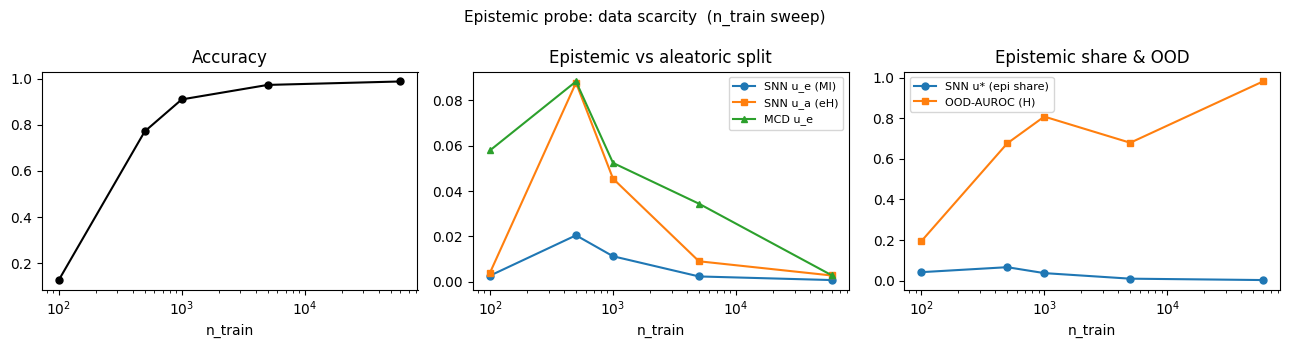

In [12]:
# Train SNN / MC Dropout / EDL on progressively smaller fractions of MNIST.
# With less data, trust parameters have fewer gradient steps to converge →
# they stay in the diffuse epistemic_flat / epistemic_u regime → different outer
# trust draws make DIFFERENT predictions → MI (u_e) rises.

n_train_levels = [100, 500, 1000, 5000, 60000]
epi_rows = []
for n in n_train_levels:
    a = run_mnist.build_argparser().parse_args([])
    a.arch, a.device, a.epochs = args.arch, args.device, args.epochs
    a.n_train, a.label_noise, a.no_cache = n, 0.0, False
    r = run_cached(f"epi_n{n}", a)
    s0  = r["sweep"][0]   # angle=0°  (in-distribution, no rotation)
    tbl = {row["name"]: row for row in r["table"]}
    epi_rows.append({
        "n_train":      n,
        "acc":          round(s0[1],  4),
        "snn_u_e (MI)": round(s0[3],  5),
        "snn_u_a (eH)": round(s0[4],  5),
        "snn_u*":       round(s0[2],  4),
        "mcd_u_e":      round(s0[10], 5),
        "ood_auroc_H":  round(tbl["SNN (mean, H)"]["ood_auroc"], 4),
    })

df_epi = pd.DataFrame(epi_rows)
display(df_epi)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    axes[0].semilogx(df_epi["n_train"], df_epi["acc"], "k-o", ms=5)
    axes[0].set_xlabel("n_train"); axes[0].set_title("Accuracy")
    axes[1].semilogx(df_epi["n_train"], df_epi["snn_u_e (MI)"], "-o", ms=5, label="SNN u_e (MI)")
    axes[1].semilogx(df_epi["n_train"], df_epi["snn_u_a (eH)"], "-s", ms=5, label="SNN u_a (eH)")
    axes[1].semilogx(df_epi["n_train"], df_epi["mcd_u_e"],      "-^", ms=5, label="MCD u_e")
    axes[1].set_xlabel("n_train"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    axes[2].semilogx(df_epi["n_train"], df_epi["snn_u*"],      "-o", ms=5, label="SNN u* (epi share)")
    axes[2].semilogx(df_epi["n_train"], df_epi["ood_auroc_H"], "-s", ms=5, label="OOD-AUROC (H)")
    axes[2].set_xlabel("n_train"); axes[2].set_title("Epistemic share & OOD")
    axes[2].legend(fontsize=8)
    fig.suptitle("Epistemic probe: data scarcity  (n_train sweep)", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_epistemic_n_train.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 5. Aleatoric probe — label noise

Train on all 60 k MNIST images but randomly flip `label_noise` fraction of training labels.
The test set is always **clean** — any uncertainty on test images reflects the noisy decision boundary baked in during training.

Expected: **`u_a` (eH) ↑** as noise rises; `u_e` (MI) lower than the data-scarcity case because trust draws agree on *what* is uncertain even when they can't agree on a class (aleatoric regime: α ≈ β >> 1).

arch=resnet  train=60000  test=10000  hidden=256

[training SNN]


Epoch 1/15: 100%|██████████| 937/937 [00:14<00:00, 64.99it/s]


  ep   1/15 loss=0.1711 tr_acc=0.9498 te_acc=0.9765 kl=23.0 beta=6.66 std(E[p])=0.0056


Epoch 2/15: 100%|██████████| 937/937 [00:14<00:00, 63.05it/s]


  ep   2/15 loss=0.0588 tr_acc=0.9835 te_acc=0.9853 kl=20.0 beta=10.00 std(E[p])=0.0036


...

  135°  acc=0.318  SNN u*=0.039 u_e=0.0107  MCD u*=0.016 u_e=0.0257  H=0.608


  150°  acc=0.405  SNN u*=0.032 u_e=0.0095  MCD u*=0.016 u_e=0.0257  H=0.590


  165°  acc=0.433  SNN u*=0.030 u_e=0.0088  MCD u*=0.017 u_e=0.0257  H=0.579


  180°  acc=0.435  SNN u*=0.026 u_e=0.0074  MCD u*=0.017 u_e=0.0254  H=0.563
[results] saved → results/cache/alea_noise40_6edfbb43b485_results.json


,label_noise,acc,snn_u_e (MI),snn_u_a (eH),snn_u*,mcd_u_e,mcd_u_a
0,0.0,0.992,0.00060,0.00309,0.0032,0.00347,0.02210
1,0.1,0.990,0.00026,0.00079,0.0012,0.01951,0.45661
2,0.2,0.994,0.00035,0.00152,0.0019,0.02456,0.89210
3,0.4,0.988,0.00104,0.00503,0.0023,0.02489,1.41514


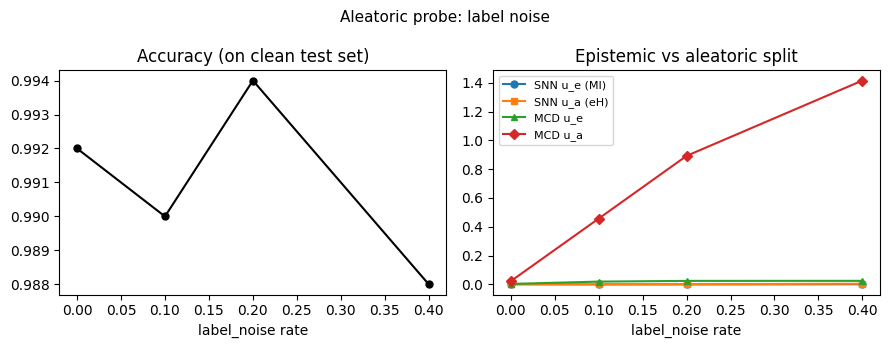

In [13]:
# Train on all 60 k MNIST images but randomly flip `label_noise` fraction of labels.
# Test set is always CLEAN — any uncertainty on test images reflects the noisy boundary
# baked in during training (pure aleatoric: same input can appear with different labels).
#
# Expected decomposition on clean test images:
#   u_a (eH) ↑  — model learns an irreducibly uncertain boundary; each trust draw is less sharp
#   u_e (MI) lower than in the data-scarcity case — trust draws AGREE on their uncertainty
#   (contrast Sec 4 where draws DISAGREE on the correct prediction → high MI)

noise_levels = [0.0, 0.1, 0.2, 0.4]
alea_rows = []
for rate in noise_levels:
    a = run_mnist.build_argparser().parse_args([])
    a.arch, a.device, a.epochs = args.arch, args.device, args.epochs
    a.n_train, a.label_noise, a.no_cache = 60000, rate, False
    r = run_cached(f"alea_noise{int(rate * 100):02d}", a)
    s0 = r["sweep"][0]   # angle=0°  (clean in-distribution)
    alea_rows.append({
        "label_noise":   rate,
        "acc":           round(s0[1],  4),
        "snn_u_e (MI)":  round(s0[3],  5),
        "snn_u_a (eH)":  round(s0[4],  5),
        "snn_u*":        round(s0[2],  4),
        "mcd_u_e":       round(s0[10], 5),
        "mcd_u_a":       round(s0[11], 5),
    })

df_alea = pd.DataFrame(alea_rows)
display(df_alea)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].plot(df_alea["label_noise"], df_alea["acc"], "k-o", ms=5)
    axes[0].set_xlabel("label_noise rate"); axes[0].set_title("Accuracy (on clean test set)")
    axes[1].plot(df_alea["label_noise"], df_alea["snn_u_e (MI)"],  "-o", ms=5, label="SNN u_e (MI)")
    axes[1].plot(df_alea["label_noise"], df_alea["snn_u_a (eH)"],  "-s", ms=5, label="SNN u_a (eH)")
    axes[1].plot(df_alea["label_noise"], df_alea["mcd_u_e"],       "-^", ms=5, label="MCD u_e")
    axes[1].plot(df_alea["label_noise"], df_alea["mcd_u_a"],       "-D", ms=5, label="MCD u_a")
    axes[1].set_xlabel("label_noise rate"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    fig.suptitle("Aleatoric probe: label noise", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_aleatoric_label_noise.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 6. Aleatoric probe — pixel noise at inference

No retraining: add Gaussian noise N(0, σ²) to clean test images and re-run inference on the baseline model.

Each trust draw sees the **same noisy image** and is individually uncertain → eH rises.
Cross-draw disagreement (MI) stays low because all trust draws face the same ambiguous input.

Expected:  **`snn_u_a` (eH) ↑** as σ grows; **`snn_u_e` (MI) stays flat**; `u* = MI/H` stays low.


[training SNN]


Epoch 1/15: 100%|██████████| 31/31 [00:00<00:00, 57.75it/s]


  ep   1/15 loss=1.6203 tr_acc=0.4682 te_acc=0.6770 kl=23.1 beta=6.45 std(E[p])=0.0014


Epoch 2/15: 100%|██████████| 31/31 [00:00<00:00, 64.91it/s]


  ep   2/15 loss=0.5557 tr_acc=0.8800 te_acc=0.7875 kl=22.2 beta=10.00 std(E[p])=0.0019


...

Epoch 14/15: 100%|██████████| 31/31 [00:00<00:00, 68.73it/s]


  ep  14/15 loss=0.1846 tr_acc=0.9728 te_acc=0.9265 lam=1.00


Epoch 15/15: 100%|██████████| 31/31 [00:00<00:00, 69.99it/s]


  ep  15/15 loss=0.1790 tr_acc=0.9693 te_acc=0.8840 lam=1.00
[models] saved → results/models/run_mnist_a99d9aa153e1/


,sigma,acc,snn_u_e,snn_u_a,snn_u,mcd_u_e,mcd_u_a,edl_u
0,0.00,0.9335,0.007794,0.032520,0.025544,0.032301,0.135509,0.332043
1,0.05,0.9245,0.008056,0.032432,0.026590,0.074905,0.310211,0.339838
2,0.10,0.8890,0.009310,0.040531,0.033261,0.101820,0.418489,0.421037
3,0.20,0.3365,0.026592,0.116542,0.083705,0.017827,0.079463,0.514769
4,0.40,0.1040,0.000580,0.002251,0.003412,0.002483,0.013430,0.789463
5,0.80,0.1040,0.009207,0.030764,0.053491,0.002803,0.015222,0.655956


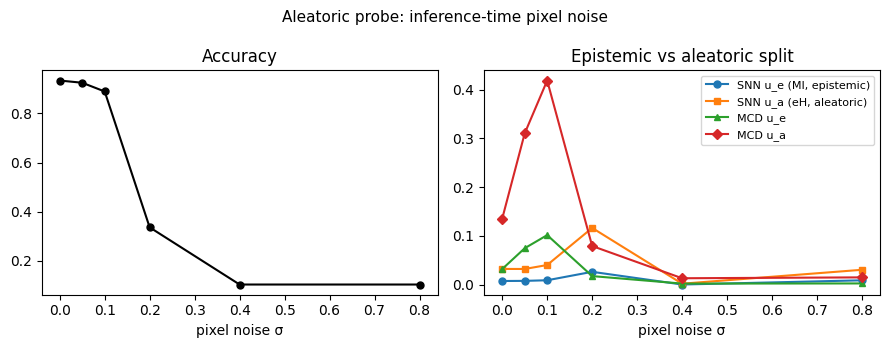

In [14]:
import torchvision as tv, torchvision.transforms as T
import torch, os

# Load baseline trained models from cache (no retraining if Section 1 already ran).
base_args = run_mnist.build_argparser().parse_args([])
base_args.arch, base_args.device, base_args.epochs = args.arch, args.device, args.epochs
base_args.n_train, base_args.label_noise = 60000, 0.0

tf = T.ToTensor()
te_ds = tv.datasets.MNIST("./data", train=False, download=True, transform=tf)
n_probe = 2000
Xte_i = torch.stack([te_ds[i][0] for i in range(n_probe)])
yte   = torch.tensor([te_ds[i][1] for i in range(n_probe)])

tr_ds  = tv.datasets.MNIST("./data", train=True, download=True, transform=tf)
Xtr_i2 = torch.stack([tr_ds[i][0] for i in range(min(2000, len(tr_ds)))])
ytr2   = torch.tensor([tr_ds[i][1] for i in range(len(Xtr_i2))])

heads = run_mnist.build_or_train_models(
    base_args, K=10,
    Xtr=run_mnist._prep_inputs(Xtr_i2, base_args.arch), ytr=ytr2,
    Xte=run_mnist._prep_inputs(Xte_i,  base_args.arch), yte=yte,
    exp_name="run_mnist"
)

os.makedirs("results", exist_ok=True)
noise_rows = run_mnist.pixel_noise_probe(
    heads, Xte_i, yte, base_args, K=10,
    sigmas=[0.0, 0.05, 0.1, 0.2, 0.4, 0.8]
)
df_noise = pd.DataFrame(noise_rows)
display(df_noise[["sigma", "acc", "snn_u_e", "snn_u_a", "snn_u", "mcd_u_e", "mcd_u_a", "edl_u"]])

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].plot(df_noise["sigma"], df_noise["acc"], "k-o", ms=5)
    axes[0].set_xlabel("pixel noise σ"); axes[0].set_title("Accuracy")
    axes[1].plot(df_noise["sigma"], df_noise["snn_u_e"], "-o", ms=5, label="SNN u_e (MI, epistemic)")
    axes[1].plot(df_noise["sigma"], df_noise["snn_u_a"], "-s", ms=5, label="SNN u_a (eH, aleatoric)")
    axes[1].plot(df_noise["sigma"], df_noise["mcd_u_e"], "-^", ms=5, label="MCD u_e")
    axes[1].plot(df_noise["sigma"], df_noise["mcd_u_a"], "-D", ms=5, label="MCD u_a")
    axes[1].set_xlabel("pixel noise σ"); axes[1].set_title("Epistemic vs aleatoric split")
    axes[1].legend(fontsize=8)
    fig.suptitle("Aleatoric probe: inference-time pixel noise", fontsize=11)
    fig.tight_layout()
    plt.savefig("results/probe_aleatoric_pixel_noise.png", dpi=140)
    plt.show()
except ImportError:
    pass


## 7. Epistemic probe — unseen classes (class-split OOD)

Train on digits 0–4 only; OOD = digits 5–9 the model has never seen.
This is a controlled epistemic gap: the model has the capacity but lacks training signal for those output directions, so trust parameters for unseen-class feature regions should stay diffuse → high MI (u_e).

Expected:  OOD-AUROC high for `u_e` / `u*` / `H`; `u_e >> u_a` on the unseen-class split.

arch=resnet  train=30596  test=1000  hidden=256

[training SNN]


Epoch 1/15: 100%|██████████| 478/478 [00:07<00:00, 64.04it/s]


  ep   1/15 loss=0.1015 tr_acc=0.9682 te_acc=0.9420 kl=22.2 beta=6.65 std(E[p])=0.0050


Epoch 2/15: 100%|██████████| 478/478 [00:07<00:00, 65.81it/s]

  ep   2/15 loss=0.0350 tr_acc=0.9913 te_acc=0.9960 kl=18.3 beta=10.00 std(E[p])=0.0025


...

  MC Dropout (T=100, OOD)...


  EDL opinion (ID + OOD)...
  done.

Rotation sweep (200 digits, 3 angles) ...


    0°  acc=0.995  SNN u*=0.002 u_e=0.0001  MCD u*=0.122 u_e=0.0004  H=0.366


   90°  acc=0.240  SNN u*=0.031 u_e=0.0089  MCD u*=0.109 u_e=0.0219  H=0.458


  180°  acc=0.595  SNN u*=0.028 u_e=0.0078  MCD u*=0.082 u_e=0.0126  H=0.442
[results] saved → results/cache/class_split_0to4_8fbc835f64aa_results.json

Class-split OOD probe  (train=digits 0–4, OOD=digits 5–9):

arch=resnet

Model                 Acc    NLL    ECE OOD-AUROC
MC Dropout          0.999  0.003  0.001     0.976
MCD (mean, H)       0.999  0.003  0.001     0.977
MCD (u* BALD)       0.999  0.003  0.001     0.122
EDL                 0.994  0.048  0.032     0.942
SNN (mean, H)       0.996  0.015  0.004     0.959
SNN (u* counts)     0.996  0.015  0.004     0.366
SNN (aug P soft)    0.996  0.107  0.091     0.191

Rotation sweep (means over 200 digits)
  deg |   acc  SNN u*  SNN u_e SNN u_a SNN H  | MCD H  MCD epi MCD ale | MCD u* MCD u_e MCD u_a | EDL u  EDL H 
    0 | 0.995  0.002   0.0001  0.000   0.366  | 0.007  0.0001  0.004   | 0.122  0.0004  0.007   | 0.040  0.184 
   90 | 0.240  0.031   0.0089  0.043   0.458  | 0.238  0.0109  0.112   | 0.109  0.0219  0.216   | 0.348  0.730

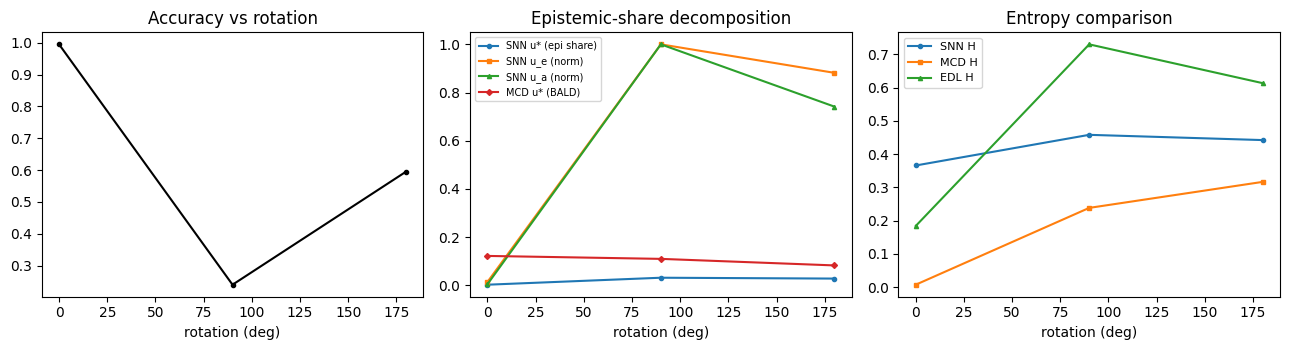

In [15]:

# Train only on digits 0–4; OOD = digits 5–9 (model has no training signal there).
# Expected: high u_e (MI) on unseen-class images — trust parameters remain diffuse
# for feature regions the model has never trained on (pure epistemic gap).

def load_split():
    return run_mnist.load_mnist_class_split(id_classes=(0, 1, 2, 3, 4), nte=1000)

a_split = run_mnist.build_argparser().parse_args([])
a_split.arch, a_split.device, a_split.epochs = args.arch, args.device, args.epochs
a_split.n_train, a_split.label_noise, a_split.no_cache = 60000, 0.0, False
a_split.rot_step, a_split.rot_n = 90, 200   # shorter rotation sweep

r_split = run_cached("class_split_0to4", a_split, loader=load_split)
print("\nClass-split OOD probe  (train=digits 0–4, OOD=digits 5–9):")
fig_split = run_mnist.display(r_split, out_prefix="class_split_rotation")
